# Building a Tiny Transformer in PyTorch

> PyTorch로 처음부터 만들어보는 작은 GPT 스타일 트랜스포머

작은 셰익스피어 텍스트를 character-level로 학습시켜서, **임베딩 → 어텐션 → 트랜스포머 블록 → 학습 → 생성**까지 전체 흐름을 직접 구현해봅니다.

**다루는 내용:**
1. 셋업 & 하이퍼파라미터
2. 데이터와 토큰화 (character-level)
3. Causal Self-Attention
4. Transformer Block (LayerNorm + Attention + MLP + Residual)
5. Tiny Transformer 조립
6. 학습 (Training)
7. 텍스트 생성 (Sampling)


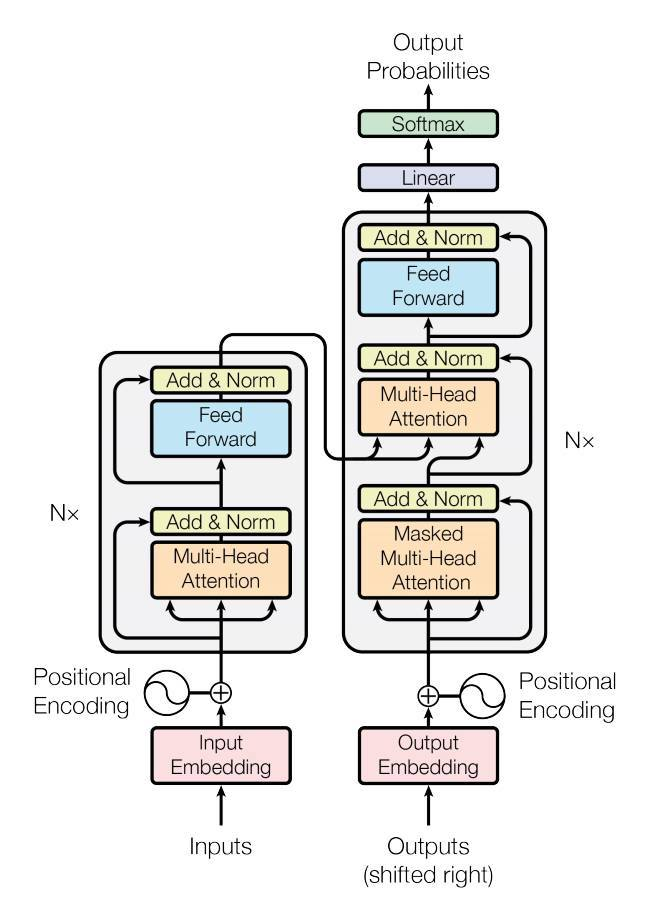

## 1. Setup: 라이브러리 import & 하이퍼파라미터

트랜스포머에는 몇 가지 핵심 하이퍼파라미터가 있음: embedding size, layer 수, head 수, context window 크기 등.


In [ ]:
import math
import torch
import torch.nn as nn
from torch.nn import functional as F

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


In [ ]:
# -------------------
# Config (CPU/GPU 모두에서 몇 분 내 학습 가능한 크기)
# -------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
block_size      = 128    # context window size (모델이 몇 글자 뒤까지 볼 수 있는지)
batch_size      = 32     # 배치당 시퀀스 개수
n_layer         = 2      # transformer block 개수
n_head          = 2      # attention head 개수
n_embd          = 128    # embedding 차원
dropout         = 0.1
max_iters       = 1200   # 학습 step 수
eval_interval   = 200
lr              = 3e-3   # learning rate
eval_iters      = 100
generate_tokens = 400    # 학습 후 생성할 문자 수

torch.manual_seed(1337)  # 재현성
print("Device:", device)


## 2. 데이터 & 토큰화

작은 셰익스피어 발췌문을 학습 데이터로 사용합니다. 데이터가 작기 때문에 **character-level** 토큰화를 사용합니다 — 모든 글자(공백, 구두점 포함)가 하나의 토큰입니다.


In [ ]:
# 셰익스피어 소네트 발췌 (Sonnet 1~3) — 데모용 작은 코퍼스
text = """
From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou, contracted to thine own bright eyes,
Feed'st thy light's flame with self-substantial fuel,
Making a famine where abundance lies,
Thyself thy foe, to thy sweet self too cruel.
Thou that art now the world's fresh ornament,
And only herald to the gaudy spring,
Within thine own bud buriest thy content,
And, tender churl, mak'st waste in niggarding.
   Pity the world, or else this glutton be,
   To eat the world's due, by the grave and thee.

When forty winters shall besiege thy brow,
And dig deep trenches in thy beauty's field,
Thy youth's proud livery, so gazed on now,
Will be a tatter'd weed, of small worth held:
Then being ask'd where all thy beauty lies,
Where all the treasure of thy lusty days;
To say, within thine own deep-sunken eyes,
Were an all-eating shame and thriftless praise.
How much more praise deserved thy beauty's use,
If thou couldst answer 'This fair child of mine
Shall sum my count and make my old excuse,'
Proving his beauty by succession thine!
   This were to be new made when thou art old,
   And see thy blood warm when thou feel'st it cold.

Look in thy glass, and tell the face thou viewest
Now is the time that face should form another;
Whose fresh repair if now thou not renewest,
Thou dost beguile the world, unbless some mother.
For where is she so fair whose unear'd womb
Disdains the tillage of thy husbandry?
Or who is he so fond will be the tomb
Of his self-love, to stop posterity?
Thou art thy mother's glass, and she in thee
Calls back the lovely April of her prime:
So thou through windows of thine age shall see
Despite of wrinkles this thy golden time.
   But if thou live, remember'd not to be,
   Die single, and thine image dies with thee.
"""

print(f"Total characters: {len(text)}")
print(f"First 200 chars:\n{text[:200]}")


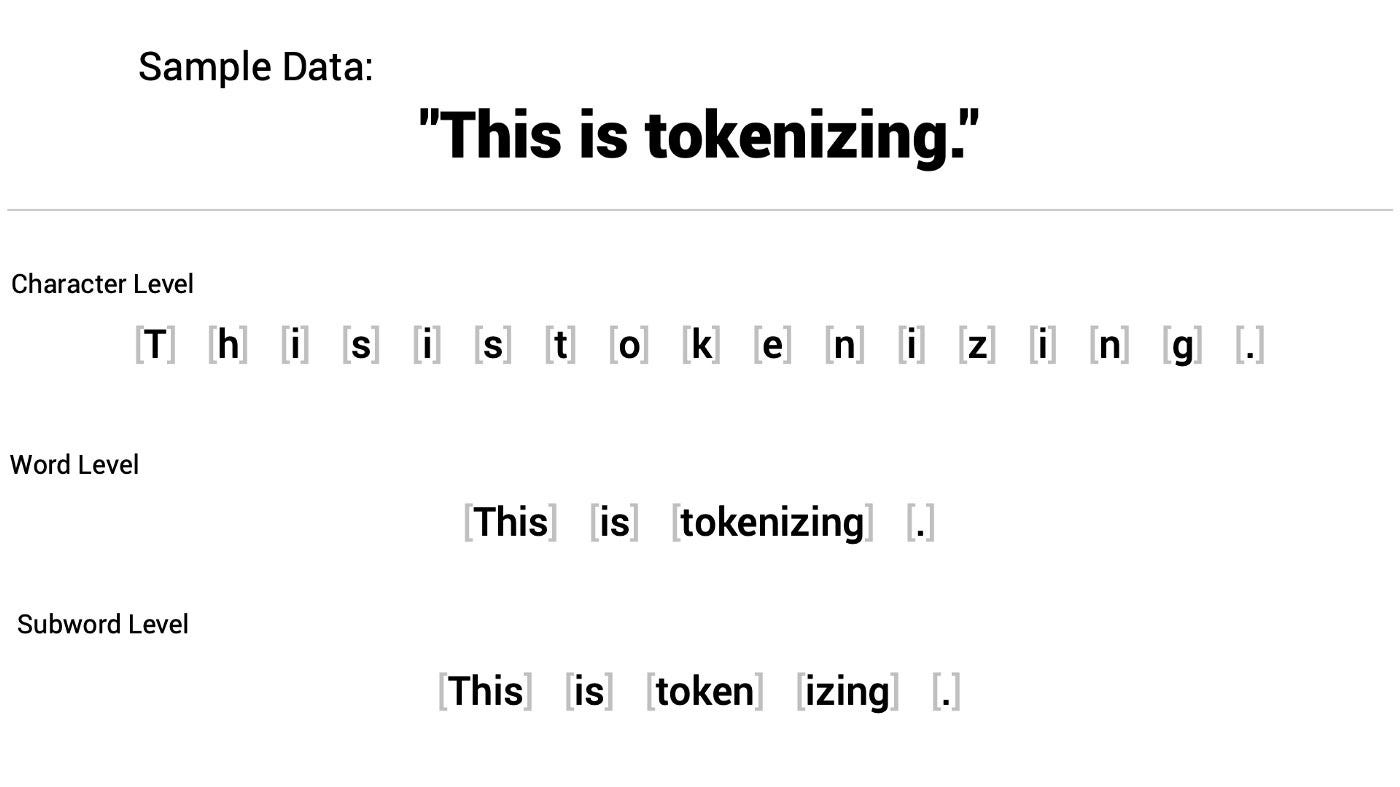

In [ ]:
# -------------------
# 토큰화 (character-level)
# -------------------
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}  # char → index
itos = {i: ch for ch, i in stoi.items()}      # index → char

encode = lambda s: torch.tensor([stoi[c] for c in s], dtype=torch.long)
decode = lambda t: ''.join(itos[int(i)] for i in t)

print(f"Vocab size: {vocab_size}")
print(f"Chars: {''.join(chars)}")
print(f"\nencode('Hello'): {encode('Hello' if all(c in stoi for c in 'Hello') else chars[0])}")


In [ ]:
# Train/Validation split
data = encode(text)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print(f"Train data length: {len(train_data)}")
print(f"Val data length: {len(val_data)}")

# 미니배치 샘플링 함수
def get_batch(split):
    d = train_data if split == 'train' else val_data
    cur_block = min(block_size, max(2, len(d) - 2))
    hi = len(d) - cur_block - 1
    if hi <= 0:
        x = d[:cur_block].unsqueeze(0)
        y = d[1:cur_block+1].unsqueeze(0)
        return x.to(device), y.to(device)
    ix = torch.randint(hi, (batch_size,))
    x = torch.stack([d[i:i+cur_block] for i in ix])
    y = torch.stack([d[i+1:i+cur_block+1] for i in ix])
    return x.to(device), y.to(device)

# 테스트
xb, yb = get_batch('train')
print(f"\nBatch x shape: {xb.shape}, y shape: {yb.shape}")


## 3. Attention

임베딩이 토큰을 *표현*하는 방식이라면, 어텐션은 모델이 시퀀스 안에서 어디에 집중할지 결정함.

### Q, K, V (Query, Key, Value)
각 토큰 임베딩은 세 개의 벡터로 변환됨:
- **Query (Q):** 내가 찾고 있는 것
- **Key (K):** 내가 가지고 있는 것
- **Value (V):** 선택되었을 때 제공할 정보

### Scaled Dot-Product Attention
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

- $QK^\top$: query와 key의 유사도
- $\sqrt{d_k}$로 나누기: 값이 너무 커져서 학습이 불안정해지는 것 방지
- softmax: 유사도를 확률로 변환
- $V$ 곱: 시퀀스로부터 정보 집계

### Causal Masking (Decoder)
언어 모델링에서는 각 토큰이 과거 토큰만 볼 수 있어야 함. 미래를 보면 다음 토큰 예측이 사실상 정답을 보고 푸는 셈이 되니까. 그래서 **causal mask** 로 미래 위치를 차단함.

In [ ]:
class CausalSelfAttention(nn.Module):
    """
    Causal masking이 적용된 Multi-head self-attention.
    (모델이 미래 토큰을 보지 못하도록 함)
    """
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        # Q, K, V projection
        self.key   = nn.Linear(n_embd, n_embd, bias=False)
        self.query = nn.Linear(n_embd, n_embd, bias=False)
        self.value = nn.Linear(n_embd, n_embd, bias=False)
        self.proj  = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # Causal mask: 미래 토큰 차단
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        )

    def forward(self, x):
        B, T, C = x.size()
        # Linear projection → head 단위로 split
        k = self.key(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = self.query(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = self.value(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        # Scaled dot-product attention
        att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))  # causal mask (query, key)
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)

        # Value 가중합
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.proj(y))
        return y

print("CausalSelfAttention defined.")


## 4. Transformer Block

Transformer Block은 attention을 감싸는 단위 모듈임. 이 블록을 여러 개 쌓아서 깊은 모델을 만듦. 현대 LLM은 대부분 이 블록을 수십~수백 개 쌓은 구조임.

블록의 구성 요소:
1. **Layer Normalization** — 학습 안정화
2. **Multi-Head Self-Attention** — 토큰 간 의존성 포착
3. **Feedforward Network (MLP)** — 비선형 변환

그리고 **Residual Connection** — 신호가 층을 통과하며 사라지지 않도록 하는 skip connection.

### 수식

$$x = x + \text{Attention}(\text{LayerNorm}(x))$$
$$x = x + \text{MLP}(\text{LayerNorm}(x))$$

각 sub-layer **앞**에 LayerNorm을 두는 **Pre-Norm** 방식 (GPT, LLaMA에서 사용). 깊은 모델에서 gradient 안정성에 도움이 됨.

In [ ]:
class MLP(nn.Module):
    """각 transformer block 내부의 feedforward network."""
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # 확장
            nn.GELU(),                       # 비선형성
            nn.Linear(4 * n_embd, n_embd),  # 원래 차원으로 복원
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Transformer block = LayerNorm + Attention + MLP + residuals"""
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, dropout)
        self.ln2  = nn.LayerNorm(n_embd)
        self.mlp  = MLP(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))  # residual #1
        x = x + self.mlp(self.ln2(x))   # residual #2
        return x

print("MLP and Block defined.")


## 5. Tiny Transformer 조립

지금까지 준비한 구성 요소:
- **Embeddings**: 토큰과 위치 표현
- **Attention**: 토큰 간 정보 교환
- **MLPs**: 정보 혼합
- **Residual + LayerNorm**: 안정화

이걸 합쳐서 GPT 스타일 언어 모델을 만듦.

### Token & Positional Embeddings
트랜스포머는 token ID(정수)만 입력으로 받음. **embedding matrix**가 token ID를 dense vector로 변환함.

embedding만으로는 토큰의 **순서** 정보가 없음. "dog bites man"과 "man bites dog"이 구분이 안 됨. 그래서 **positional embedding**을 더해서 위치 정보를 주입함.

### Weight Tying
`self.head.weight = self.tok_emb.weight` — 입력 embedding과 출력 projection이 같은 행렬을 공유함. 파라미터 수가 줄고 성능에도 도움이 되는 경우가 많음.

In [ ]:
class TinyTransformer(nn.Module):
    """GPT 스타일 tiny transformer (sinusoidal positional encoding)."""
    def __init__(self):
        super().__init__()
        # Token embedding (positional embedding은 학습하지 않음)
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.drop    = nn.Dropout(dropout)
        # Transformer block 스택
        self.blocks  = nn.Sequential(*[Block(n_embd, n_head, dropout) for _ in range(n_layer)])
        self.ln_f    = nn.LayerNorm(n_embd)
        # Vocab size로의 출력 projection
        self.head    = nn.Linear(n_embd, vocab_size, bias=False)
        # Weight tying
        self.head.weight = self.tok_emb.weight

        pe = torch.zeros(block_size, n_embd)
        position = torch.arange(0, block_size, dtype=torch.float).unsqueeze(1)  # (block_size, 1)
        div_term = torch.exp(
            torch.arange(0, n_embd, 2, dtype=torch.float) * (-math.log(10000.0) / n_embd)
        )  # (n_embd/2,)
        pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 차원
        pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 차원
        self.register_buffer('pos_emb', pe)            # (block_size, n_embd)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.tok_emb(idx)        # (B, T, C)
        pos = self.pos_emb[:T]         # (T, C) — 미리 계산된 sinusoidal PE에서 잘라옴
        x = self.drop(tok + pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)          # (B, T, V)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        """다음 토큰을 반복 샘플링해서 텍스트 생성."""
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_id), dim=1)
        return idx

print("TinyTransformer (sinusoidal PE) defined.")

In [ ]:
# 모델 초기화 + 파라미터 수 확인
model = TinyTransformer().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params:,} ({n_params/1e6:.3f}M)")
print(model)


## 6. 학습 (Training)

다음 토큰을 예측하고, cross-entropy loss를 계산하고, weight를 업데이트하는 루프.

- Optimizer: AdamW
- Loss: cross-entropy (forward에 이미 포함)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = []
        for _ in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses.append(loss.item())
        out[split] = sum(losses) / len(losses)
    model.train()
    return out


In [ ]:
# -------------------
# Training loop
# -------------------
for it in range(max_iters + 1):
    if it % eval_interval == 0:
        losses = estimate_loss()
        print(f"iter {it:4d} | train loss {losses['train']:.3f} | val loss {losses['val']:.3f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

print("\nTraining complete!")


## 7. 텍스트 생성 (Sampling)

학습이 끝나면, 빈 context에서 시작해서 모델이 다음 토큰을 반복적으로 샘플링함. 데이터가 작고 모델도 tiny하기 때문에 생성 품질보다는 **아키텍처 동작 확인**이 목적임.

In [ ]:
# 빈 context (token 0)으로 시작
context = torch.zeros((1, 1), dtype=torch.long, device=device)
sample = model.generate(context, max_new_tokens=generate_tokens)[0].tolist()

print("--- SAMPLE ---\n")
print(decode(sample))


In [ ]:
# 직접 prompt를 줘서 생성해보기
prompt = "From "
prompt_ids = encode(prompt).unsqueeze(0).to(device)
sample = model.generate(prompt_ids, max_new_tokens=300)[0].tolist()

print(f"--- SAMPLE (prompt: {prompt!r}) ---\n")
print(decode(sample))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import types

def forward_with_attn(self, x):
    B, T, C = x.size()
    k = self.key(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
    q = self.query(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
    v = self.value(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

    att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
    att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
    att = F.softmax(att, dim=-1)
    self.last_attn = att.detach().cpu()   # ← 여기서 저장
    att = self.attn_drop(att)

    y = att @ v
    y = y.transpose(1, 2).contiguous().view(B, T, C)
    y = self.resid_drop(self.proj(y))
    return y

# 모든 block의 attention 모듈에 적용
for block in model.blocks:
    block.attn.forward = types.MethodType(forward_with_attn, block.attn)

# ---- 2. "From "을 넣고 forward 한 번 실행 ----
prompt = "From "
prompt_ids = encode(prompt).unsqueeze(0).to(device)
tokens = list(prompt)  # ['F', 'r', 'o', 'm', ' ']

model.eval()
with torch.no_grad():
    _ = model(prompt_ids)

# ---- 3. 시각화: layer × head grid ----
fig, axes = plt.subplots(n_layer, n_head, figsize=(4 * n_head, 4 * n_layer),
                          squeeze=False)

for layer_idx, block in enumerate(model.blocks):
    attn = block.attn.last_attn[0]  # (n_head, T, T) — batch 0번
    for head_idx in range(n_head):
        ax = axes[layer_idx][head_idx]
        a = attn[head_idx].numpy()
        im = ax.imshow(a, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f"Layer {layer_idx} · Head {head_idx}")
        # 토큰 라벨 (공백은 '␣'로 표시)
        labels = [t if t != ' ' else '␣' for t in tokens]
        ax.set_xticks(range(len(tokens)))
        ax.set_yticks(range(len(tokens)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)
        ax.set_xlabel("Key (attended to)")
        ax.set_ylabel("Query (from)")
        # 각 셀에 숫자 표시
        for i in range(len(tokens)):
            for j in range(len(tokens)):
                ax.text(j, i, f"{a[i, j]:.2f}",
                        ha='center', va='center',
                        color='white' if a[i, j] < 0.5 else 'black',
                        fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### 추가 실습
- `n_layer`, `n_head`, `n_embd`를 늘려보고 loss 곡선/생성 품질 비교
- `block_size`를 늘려서 context를 더 길게